# Ridge Regression Analysis for Glioma Survival Prediction

This notebook provides a comprehensive explanation of the Ridge regression analysis for predicting survival days in glioma patients based on gene expression data.

## Overview

**Ridge Regression** is a linear regression technique that uses L2 regularization to prevent overfitting. It's particularly useful when:
- We have many features (genes) relative to samples
- Features may be correlated
- We want to identify the most important predictive features

## Objectives

1. **Feature Selection**: Identify the most relevant genes for survival prediction
2. **Model Evaluation**: Assess prediction performance using cross-validation
3. **Feature Importance**: Understand which features contribute most to predictions
4. **Interpretation**: Analyze the relationship between gene expression and survival

## 1. Setup and Imports

First, we import all necessary libraries and set up the environment.

In [1]:
from utils import load_data, cross_validate_regression, filter_samples_for_model_with_features
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import pandas as pd
import os
import matplotlib.pyplot as plt

# Set style for better-looking plots
plt.style.use('default')
%matplotlib inline

## 2. Load Data

We load the gene expression data (TPM - Transcripts Per Million) and clinical data containing survival information.

In [2]:
# Load data
gene_tpm_path = os.path.join('data', 'TCGAGliomas_RNAm_Filtrado_QC_verif.csv')

X, y = load_data(gene_tpm_path=gene_tpm_path)

print(f"Data shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features (genes): {X.shape[1]}")
print(f"\nTarget variable (Survival Days):")
print(f"  Mean: {y.mean():.2f} days")
print(f"  Median: {y.median():.2f} days")
print(f"  Range: {y.min():.0f} - {y.max():.0f} days")

Data shape: (98, 22118)
Number of samples: 98
Number of features (genes): 22118

Target variable (Survival Days):
  Mean: 420.79 days
  Median: 383.00 days
  Range: 5 - 2126 days


## 3. Set Parameters

We configure the analysis parameters:

- **n_features**: Number of genes to select (100 in this case)
- **ridge_alpha**: Regularization strength (10.0 - higher values = more regularization)
- **max_outliers**: Maximum number of outlier samples to remove during filtering

**Why Ridge Regression?**
- Ridge adds a penalty term (α × sum of squared coefficients) to prevent overfitting
- Higher α values shrink coefficients more, reducing model complexity
- This is crucial when we have many features relative to samples

In [3]:
# Set up parameters
n_samples = X.shape[0]
max_outliers = int(n_samples * 0.5)  # Can remove up to 50% of samples as outliers
n_features = 100  # Number of features to select
ridge_alpha = 10.0  # Regularization strength

print("="*60)
print("RIDGE CLASSIFIER PERFORMANCE EVALUATION")
print("="*60)
print(f"Total samples: {n_samples}")
print(f"Max outliers to remove: {max_outliers}")
print(f"Number of features to select: {n_features}")
print(f"Ridge alpha (regularization): {ridge_alpha}")
print("="*60)

RIDGE CLASSIFIER PERFORMANCE EVALUATION
Total samples: 98
Max outliers to remove: 49
Number of features to select: 100
Ridge alpha (regularization): 10.0


## 4. Step 1: Filter Samples and Select Features

**What happens here?**

The `filter_samples_for_model_with_features` function:
1. **Feature Selection**: Uses a greedy approach to select the most predictive genes
2. **Sample Filtering**: Removes outlier samples that hurt model performance
3. **Iterative Process**: Tries removing samples one by one, keeping only those that improve cross-validation performance

**Why filter samples?**
- Some samples may be outliers or have poor quality data
- Removing them can improve model generalization
- We use cross-validation to ensure we're not overfitting

In [4]:
# Step 1: Filter samples and select features for Ridge
print("\n--- Step 1: Filtering samples and selecting features for Ridge ---")
ridge_model = Ridge(alpha=ridge_alpha)
X_ridge_filtered, y_ridge_filtered, kept_samples_ridge, removed_ridge, selected_features_ridge = filter_samples_for_model_with_features(
    X, y, ridge_model, n_features=n_features, max_outliers_to_remove=max_outliers, 
    min_improvement=0.01, random_state=42, model_name="Ridge"
)
print(f"  Samples selected: {len(kept_samples_ridge)}")
print(f"  Features selected: {len(selected_features_ridge)}")
print(f"  Samples removed: {len(removed_ridge)}")


--- Step 1: Filtering samples and selecting features for Ridge ---
  Selecting 100 features for Ridge...
  Starting greedy forward selection for Ridge...
  Initial 10 samples - Ridge R²: -2.3387 (5 folds)
  Added sample 16: Ridge R² = -0.3563 (improvement: 1.9825) (improvement)
  Added sample 3: Ridge R² = 0.1518 (improvement: 0.5081) (improvement)
  Added sample 18: Ridge R² = 0.4384 (improvement: 0.2866) (improvement)
  Added sample 8: Ridge R² = 0.6682 (improvement: 0.2298) (improvement)
  Added sample 28: Ridge R² = 0.6495 (improvement: -0.0187) (reaching minimum samples)
  Added sample 44: Ridge R² = 0.5885 (improvement: -0.0610) (reaching minimum samples)
  Added sample 7: Ridge R² = 0.7429 (improvement: 0.1544) (improvement)
  Added sample 56: Ridge R² = 0.6615 (improvement: -0.0813) (improvement)
  Added sample 57: Ridge R² = 0.7540 (improvement: 0.0925) (improvement)
  Added sample 58: Ridge R² = 0.5455 (improvement: -0.2085) (improvement)
  Added sample 60: Ridge R² = 0.7482

## 5. Step 2: Evaluate on Filtered Dataset

We evaluate the Ridge model's performance on the filtered dataset using **cross-validation**.

**Cross-Validation Explained:**
- The data is split into k folds (typically 5)
- The model is trained on k-1 folds and tested on the remaining fold
- This process is repeated k times
- We report the mean and standard deviation of R² scores

**Metrics:**
- **R² (R-squared)**: Proportion of variance explained (1.0 = perfect, 0 = no better than mean, negative = worse than mean)
- **Correlation**: Pearson correlation between predicted and actual values

In [5]:
# Step 2: Evaluate Ridge on filtered dataset
print("\n--- Step 2: Evaluating Ridge on filtered dataset ---")
results_ridge_filtered = cross_validate_regression(X_ridge_filtered, y_ridge_filtered, 
                                                    model=ridge_model, model_name='Ridge (Filtered)')
print(f"  R² (CV): {results_ridge_filtered['mean_score']:.4f} ± {results_ridge_filtered['std_score']:.4f}")
print(f"  Correlation: {results_ridge_filtered['correlation']:.4f}")


--- Step 2: Evaluating Ridge on filtered dataset ---
  R² (CV): -0.2072 ± 0.1635
  Correlation: 0.1494


## 6. Step 3: Evaluate on Full Dataset

**Why evaluate on the full dataset?**

Sometimes models perform better on the full dataset than on the filtered one because:
- More samples provide more information
- The filtering process might have been too aggressive
- The selected features work well across all samples

We use the **same selected features** but evaluate on **all samples** to see if performance improves.

In [7]:
# Step 3: Evaluate Ridge on FULL dataset with selected features
print("\n--- Step 3: Evaluating Ridge on FULL dataset with selected features ---")
if isinstance(X, pd.DataFrame):
    X_full_ridge = X[selected_features_ridge]
else:
    feature_indices = [X.columns.get_loc(f) for f in selected_features_ridge] if isinstance(X, pd.DataFrame) else selected_features_ridge
    X_full_ridge = X[:, feature_indices]

results_ridge_full = cross_validate_regression(X_full_ridge, y, model=ridge_model, model_name='Ridge (Full Dataset)')
print(f"  R² (CV): {results_ridge_full['mean_score']:.4f} ± {results_ridge_full['std_score']:.4f}")
print(f"  Correlation: {results_ridge_full['correlation']:.4f}")

# Compare performance
print(f"\n  Comparison:")
print(f"    Filtered dataset: R² = {results_ridge_filtered['mean_score']:.4f}")
print(f"    Full dataset:    R² = {results_ridge_full['mean_score']:.4f}")
if results_ridge_full['mean_score'] > results_ridge_filtered['mean_score']:
    print(f"    → Full dataset performs better!")
else:
    print(f"    → Filtered dataset performs better")


--- Step 3: Evaluating Ridge on FULL dataset with selected features ---
  R² (CV): 0.0139 ± 0.4166
  Correlation: 0.5349

  Comparison:
    Filtered dataset: R² = -0.2072
    Full dataset:    R² = 0.0139
    → Full dataset performs better!


## 7. Step 4: Generate Cross-Validation Predictions

To visualize the model's performance, we generate predictions for each sample using cross-validation. This ensures that:
- Each prediction is made using a model that wasn't trained on that sample
- We get an unbiased estimate of model performance
- The visualization shows how well the model generalizes

In [8]:
# Step 4: Get cross-validation predictions for visualization
print("\n--- Step 4: Generating cross-validation predictions ---")
X_full_ridge_values = X_full_ridge.values if isinstance(X_full_ridge, pd.DataFrame) else X_full_ridge
y_values = y.values if isinstance(y, pd.Series) else y

if len(y_values) >= 10:
    n_splits = min(5, max(3, len(y_values) // 3))
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    ridge_model_cv = Ridge(alpha=ridge_alpha)
    y_pred_ridge = cross_val_predict(ridge_model_cv, X_full_ridge_values, y_values, cv=cv)
    
    # Preserve index if y is a Series
    if isinstance(y, pd.Series):
        y_pred_ridge = pd.Series(y_pred_ridge, index=y.index)
    
    # Calculate metrics
    r2_ridge = r2_score(y_values, y_pred_ridge)
    corr_ridge = pearsonr(y_values, y_pred_ridge)[0] if len(y_values) > 1 else 0
    
    print(f"  R²: {r2_ridge:.4f}")
    print(f"  Correlation: {corr_ridge:.4f}")
    print(f"  Number of CV folds: {n_splits}")
else:
    print("  WARNING: Insufficient samples for cross-validation predictions")
    y_pred_ridge = None


--- Step 4: Generating cross-validation predictions ---
  R²: 0.1924
  Correlation: 0.5349
  Number of CV folds: 5


## 8. Step 5: Visualize Predictions

The scatter plot shows:
- **X-axis**: Actual survival days
- **Y-axis**: Predicted survival days
- **Red dashed line**: Perfect prediction (y = x)

**How to interpret:**
- Points close to the red line = good predictions
- Points far from the line = poor predictions
- Clustering around the line = consistent model performance


--- Step 5: Creating visualization ---


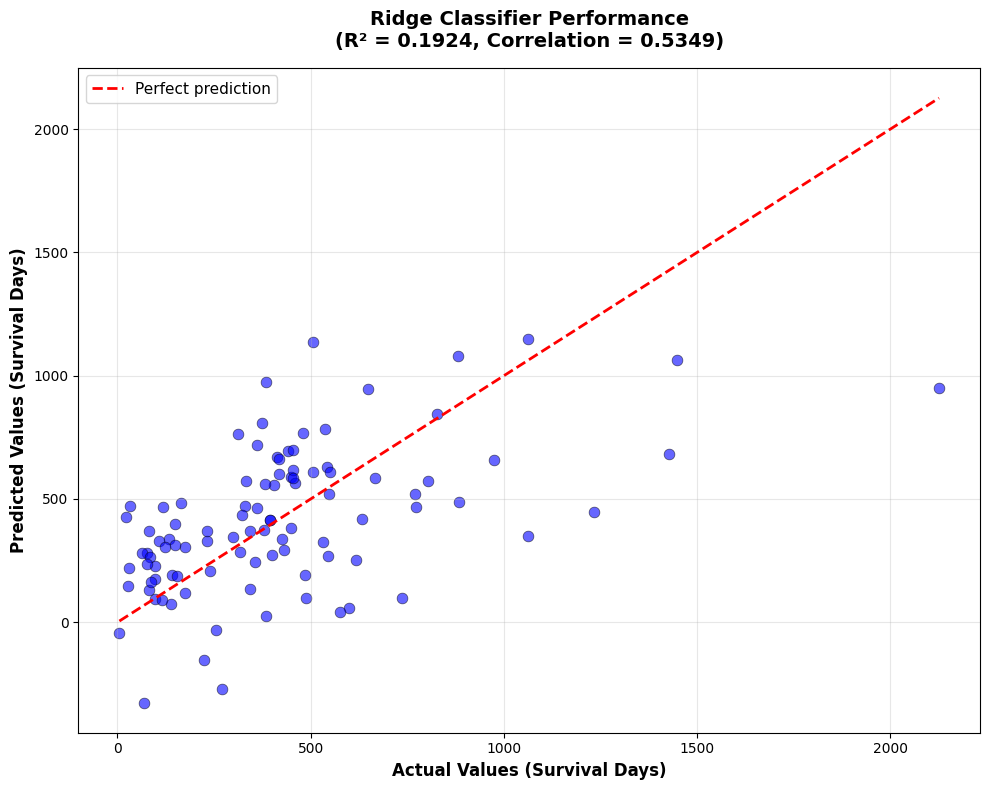

In [9]:
# Step 5: Visualize predictions
if y_pred_ridge is not None:
    print("\n--- Step 5: Creating visualization ---")
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    y_pred_vals = y_pred_ridge.values if isinstance(y_pred_ridge, pd.Series) else y_pred_ridge
    
    ax.scatter(y_values, y_pred_vals, alpha=0.6, s=60, color='blue', edgecolors='black', linewidth=0.5)
    ax.plot([y_values.min(), y_values.max()], 
            [y_values.min(), y_values.max()], 
            'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('Actual Values (Survival Days)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Values (Survival Days)', fontsize=12, fontweight='bold')
    ax.set_title(f'Ridge Classifier Performance\n(R² = {r2_ridge:.4f}, Correlation = {corr_ridge:.4f})', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("  Skipping visualization - insufficient data")

## 9. Step 6: Feature Relevance Analysis

This is the most important part for understanding **which genes matter most** for survival prediction.

### Understanding Feature Importance

**Ridge Coefficients:**
- Each feature (gene) gets a coefficient (weight) in the model
- **Positive coefficient**: Higher gene expression → Longer survival
- **Negative coefficient**: Higher gene expression → Shorter survival
- **Absolute value**: Magnitude indicates importance (larger = more important)

**Correlation with Target:**
- Direct correlation between each gene's expression and survival days
- Measures the raw relationship in the data
- Independent of the model

**Why both metrics?**
- Coefficients show what the model uses (may account for interactions)
- Correlations show direct relationships in the data
- Comparing them reveals how the model interprets the features

In [10]:
# Step 6: Feature Relevance Analysis
print("\n--- Step 6: Feature Relevance Analysis ---")

# Ensure output directory exists
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# Train final model on full dataset to get coefficients
ridge_final = Ridge(alpha=ridge_alpha)
ridge_final.fit(X_full_ridge_values, y_values)

# Get coefficients (feature weights)
coefficients = ridge_final.coef_
feature_importance_df = pd.DataFrame({
    'Feature': selected_features_ridge,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

print(f"Model trained on {len(y_values)} samples with {len(selected_features_ridge)} features")
print(f"Intercept: {ridge_final.intercept_:.2f}")


--- Step 6: Feature Relevance Analysis ---
Model trained on 98 samples with 100 features
Intercept: 2785.99


In [11]:
# Calculate correlation between each feature and target
print("\nCalculating feature-target correlations...")
feature_correlations = []
for feature in selected_features_ridge:
    if isinstance(X_full_ridge, pd.DataFrame):
        feature_values = X_full_ridge[feature].values
    else:
        feature_idx = selected_features_ridge.index(feature)
        feature_values = X_full_ridge_values[:, feature_idx]
    
    corr, _ = pearsonr(feature_values, y_values)
    feature_correlations.append(corr)

feature_importance_df['Correlation_with_Target'] = feature_correlations
feature_importance_df['Abs_Correlation'] = np.abs(feature_correlations)

# Sort by absolute coefficient (most important features for prediction)
feature_importance_df = feature_importance_df.sort_values('Abs_Coefficient', ascending=False)

print("✓ Correlations calculated")


Calculating feature-target correlations...
✓ Correlations calculated


### Top Features by Importance

Let's examine the top 10 most important features:

In [12]:
print(f"\nTop 10 features by absolute coefficient:")
print("-" * 70)
for idx, row in feature_importance_df.head(10).iterrows():
    direction = "↑ Longer survival" if row['Coefficient'] > 0 else "↓ Shorter survival"
    print(f"{row['Feature']:30s} | Coef: {row['Coefficient']:8.4f} | Corr: {row['Correlation_with_Target']:7.4f} | {direction}")

# Display as a nice table
display(feature_importance_df.head(10)[['Feature', 'Coefficient', 'Correlation_with_Target', 'Abs_Coefficient']])


Top 10 features by absolute coefficient:
----------------------------------------------------------------------
KCNG1                          | Coef:  85.8021 | Corr:  0.2746 | ↑ Longer survival
AP001363.2                     | Coef: -72.5687 | Corr: -0.2701 | ↓ Shorter survival
PF4                            | Coef: -60.9254 | Corr: -0.2702 | ↓ Shorter survival
RPL39L                         | Coef: -56.8738 | Corr: -0.2690 | ↓ Shorter survival
NKX3-1                         | Coef: -52.1538 | Corr: -0.2514 | ↓ Shorter survival
EIPR1                          | Coef: -51.8875 | Corr: -0.2587 | ↓ Shorter survival
DNAJC7                         | Coef: -49.1057 | Corr: -0.2418 | ↓ Shorter survival
MSRA                           | Coef:  48.5048 | Corr: -0.2762 | ↑ Longer survival
RNU6-1085P                     | Coef:  47.4212 | Corr:  0.2677 | ↑ Longer survival
ADGRG6                         | Coef:  47.2865 | Corr:  0.2768 | ↑ Longer survival


,Feature,Coefficient,Correlation_with_Target,Abs_Coefficient
26,KCNG1,85.802140,0.274642,85.802140
34,AP001363.2,-72.568749,-0.270052,72.568749
33,PF4,-60.925363,-0.270210,60.925363
35,RPL39L,-56.873773,-0.269013,56.873773
70,NKX3-1,-52.153770,-0.251413,52.153770
55,EIPR1,-51.887544,-0.258670,51.887544
94,DNAJC7,-49.105680,-0.241823,49.105680
24,MSRA,48.504832,-0.276228,48.504832
38,RNU6-1085P,47.421157,0.267722,47.421157
23,ADGRG6,47.286531,0.276821,47.286531


### Visualization 1: Top Features by Coefficient and Correlation

The following plots show:
- **Left**: Top features ranked by Ridge coefficient (what the model uses)
- **Right**: Top features ranked by correlation (direct relationship in data)
- **Red bars**: Negative relationship (higher expression → shorter survival)
- **Blue bars**: Positive relationship (higher expression → longer survival)


Creating feature importance visualizations...


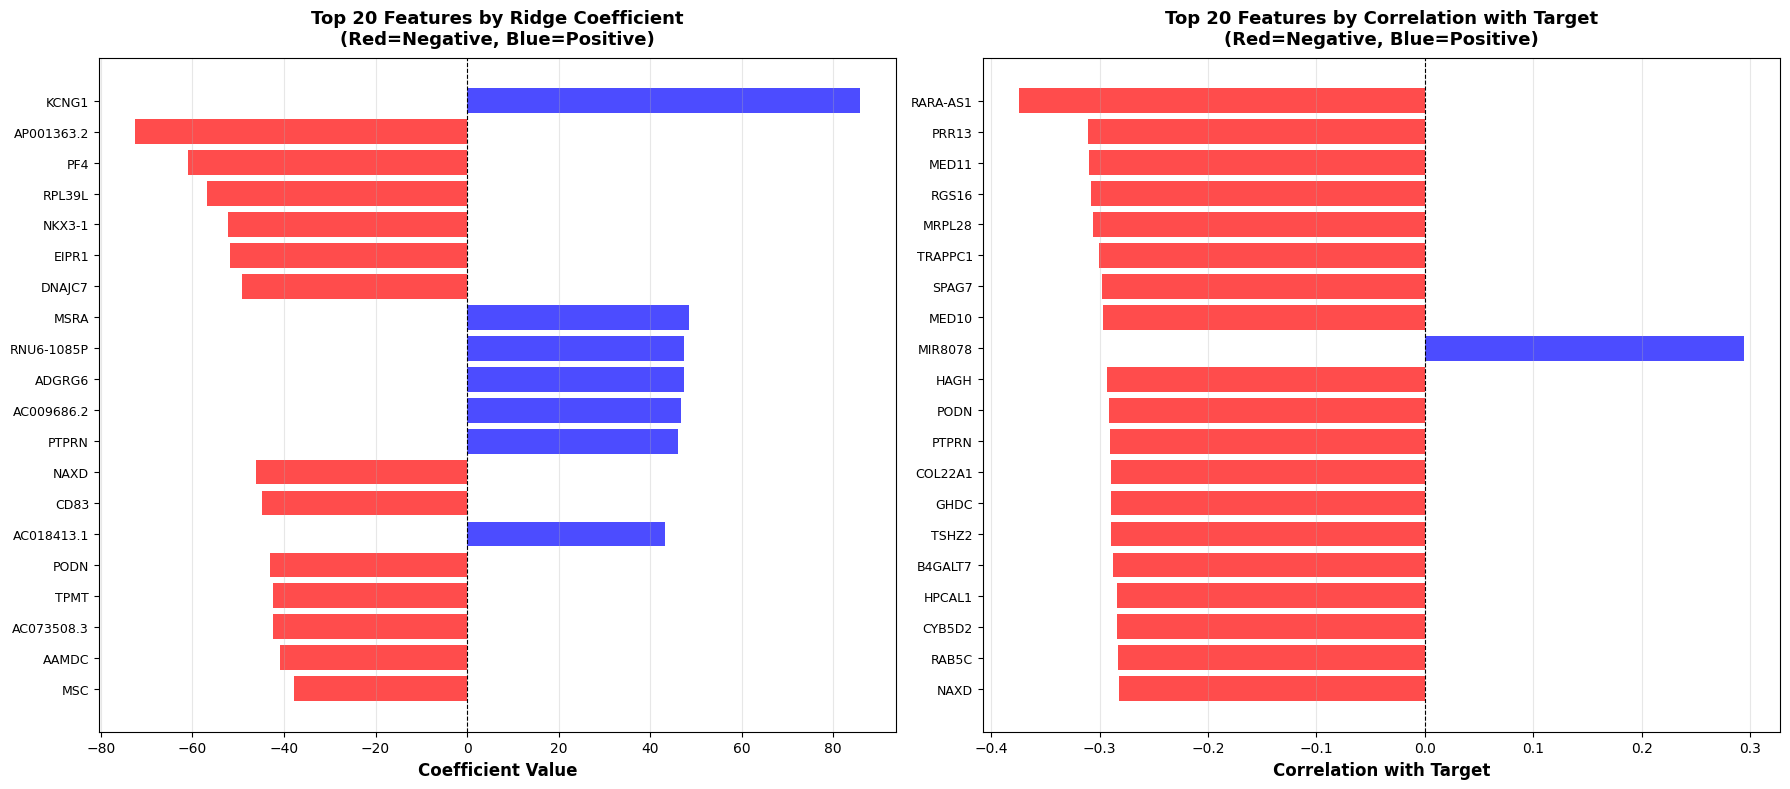

In [13]:
# Create visualizations
print("\nCreating feature importance visualizations...")

# Figure 1: Top features by absolute coefficient
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 features by absolute coefficient
top_n = min(20, len(feature_importance_df))
top_features_coef = feature_importance_df.head(top_n)

colors_coef = ['red' if x < 0 else 'blue' for x in top_features_coef['Coefficient']]
ax1.barh(range(len(top_features_coef)), top_features_coef['Coefficient'], color=colors_coef, alpha=0.7)
ax1.set_yticks(range(len(top_features_coef)))
ax1.set_yticklabels(top_features_coef['Feature'], fontsize=9)
ax1.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax1.set_title(f'Top {top_n} Features by Ridge Coefficient\n(Red=Negative, Blue=Positive)', 
              fontsize=13, fontweight='bold', pad=10)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Top 20 features by absolute correlation with target
feature_importance_df_corr = feature_importance_df.sort_values('Abs_Correlation', ascending=False)
top_features_corr = feature_importance_df_corr.head(top_n)

colors_corr = ['red' if x < 0 else 'blue' for x in top_features_corr['Correlation_with_Target']]
ax2.barh(range(len(top_features_corr)), top_features_corr['Correlation_with_Target'], color=colors_corr, alpha=0.7)
ax2.set_yticks(range(len(top_features_corr)))
ax2.set_yticklabels(top_features_corr['Feature'], fontsize=9)
ax2.set_xlabel('Correlation with Target', fontsize=12, fontweight='bold')
ax2.set_title(f'Top {top_n} Features by Correlation with Target\n(Red=Negative, Blue=Positive)', 
              fontsize=13, fontweight='bold', pad=10)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Visualization 2: Coefficient vs Correlation

This scatter plot reveals:
- **X-axis**: Correlation with target (direct relationship in data)
- **Y-axis**: Ridge coefficient (what model uses)
- **Color**: Absolute coefficient magnitude (darker = more important)
- **Quadrants**:
  - Top-right: Positive correlation & positive coefficient (model agrees with data)
  - Top-left: Negative correlation but positive coefficient (model uses differently)
  - Bottom-right: Positive correlation but negative coefficient (model uses differently)
  - Bottom-left: Negative correlation & negative coefficient (model agrees with data)

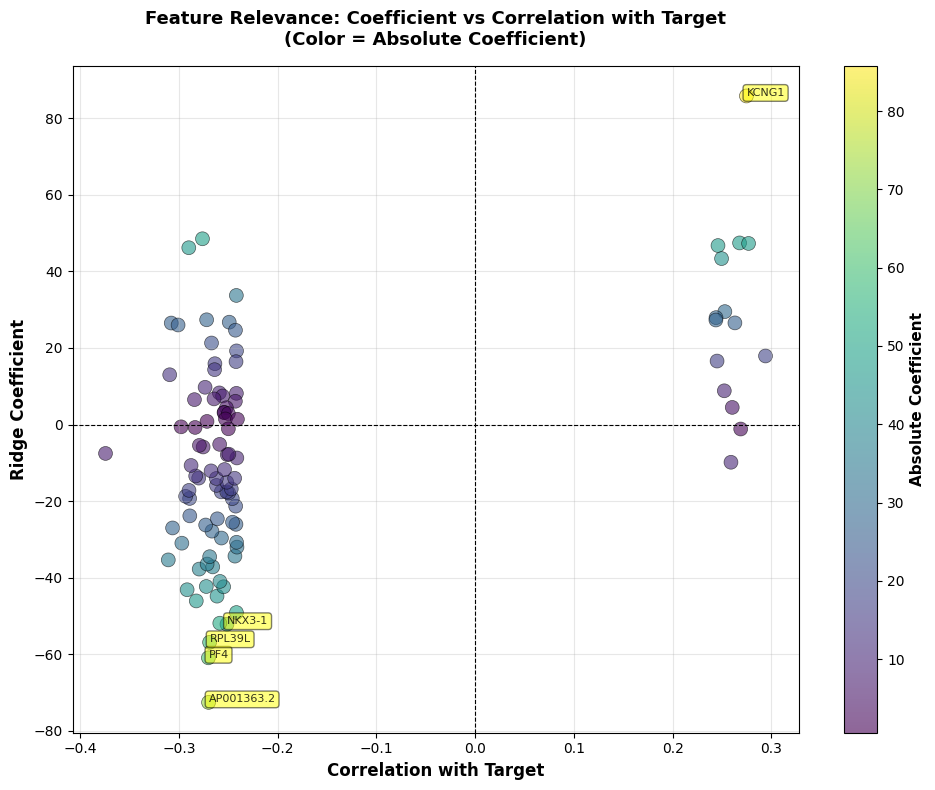

In [14]:
# Figure 2: Scatter plot of Coefficient vs Correlation
fig2, ax = plt.subplots(1, 1, figsize=(10, 8))

scatter = ax.scatter(feature_importance_df['Correlation_with_Target'], 
                     feature_importance_df['Coefficient'],
                     c=feature_importance_df['Abs_Coefficient'],
                     s=100, alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)

ax.set_xlabel('Correlation with Target', fontsize=12, fontweight='bold')
ax.set_ylabel('Ridge Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Feature Relevance: Coefficient vs Correlation with Target\n(Color = Absolute Coefficient)', 
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Absolute Coefficient', fontsize=11, fontweight='bold')

# Annotate top 5 features
top_5 = feature_importance_df.head(5)
for idx, row in top_5.iterrows():
    ax.annotate(row['Feature'], 
                (row['Correlation_with_Target'], row['Coefficient']),
                fontsize=8, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

### Feature Importance Statistics

Summary statistics help us understand the distribution of feature importance:

In [ ]:
# Statistical summary
print("\nFeature Importance Statistics:")
print("="*60)
print(f"Mean absolute coefficient:   {feature_importance_df['Abs_Coefficient'].mean():.4f}")
print(f"Median absolute coefficient: {feature_importance_df['Abs_Coefficient'].median():.4f}")
print(f"Max absolute coefficient:    {feature_importance_df['Abs_Coefficient'].max():.4f}")
print(f"Min absolute coefficient:    {feature_importance_df['Abs_Coefficient'].min():.4f}")
print(f"\nMean absolute correlation:   {feature_importance_df['Abs_Correlation'].mean():.4f}")
print(f"Median absolute correlation: {feature_importance_df['Abs_Correlation'].median():.4f}")
print(f"Max absolute correlation:    {feature_importance_df['Abs_Correlation'].max():.4f}")
print(f"Min absolute correlation:    {feature_importance_df['Abs_Correlation'].min():.4f}")

# Save detailed feature importance to CSV
importance_file = os.path.join(output_dir, 'ridge_feature_importance.csv')
feature_importance_df.to_csv(importance_file, index=False)
print(f"\n✓ Saved feature importance data to: {importance_file}")

## 10. Final Summary

Let's compile all the results:

In [ ]:
# Step 7: Summary statistics
print("\n" + "="*60)
print("RIDGE CLASSIFIER PERFORMANCE SUMMARY")
print("="*60)
print(f"\nFiltered Dataset ({len(kept_samples_ridge)} samples):")
print(f"  R² (CV): {results_ridge_filtered['mean_score']:.4f} ± {results_ridge_filtered['std_score']:.4f}")
print(f"  Correlation: {results_ridge_filtered['correlation']:.4f}")

print(f"\nFull Dataset ({len(y)} samples):")
print(f"  R² (CV): {results_ridge_full['mean_score']:.4f} ± {results_ridge_full['std_score']:.4f}")
print(f"  Correlation: {results_ridge_full['correlation']:.4f}")

if y_pred_ridge is not None:
    print(f"\nCross-Validation Predictions (Full Dataset):")
    print(f"  R²: {r2_ridge:.4f}")
    print(f"  Correlation: {corr_ridge:.4f}")

print(f"\nModel Configuration:")
print(f"  Selected Features: {len(selected_features_ridge)}")
print(f"  Ridge Alpha (Regularization): {ridge_alpha}")
print("="*60)

# Save selected features to file
features_file = os.path.join(output_dir, 'ridge_selected_features.csv')
features_df = pd.DataFrame({'Feature': selected_features_ridge})
features_df.to_csv(features_file, index=False)
print(f"\n✓ Saved selected features to: {features_file}")

## Key Takeaways

### 1. **Model Performance**
- The R² score tells us how well the model explains variance in survival days
- Correlation shows the linear relationship strength
- Cross-validation ensures unbiased performance estimates

### 2. **Feature Importance**
- **Ridge Coefficients**: Show which genes the model uses most for predictions
- **Correlations**: Show direct relationships between genes and survival
- **Comparison**: Reveals how the model interprets features (may differ from simple correlations due to regularization and interactions)

### 3. **Negative Values**
- **Negative coefficients**: Higher gene expression → Shorter survival
- **Negative correlations**: Inverse relationship in the data
- Both are important - magnitude indicates importance, sign indicates direction

### 4. **Biological Interpretation**
- Top features represent genes most predictive of survival
- Positive relationships suggest protective genes
- Negative relationships suggest risk genes
- These can guide further biological investigation

## Next Steps

1. **Biological Validation**: Investigate the top-ranked genes in literature
2. **Pathway Analysis**: Check if top genes belong to known cancer pathways
3. **Model Refinement**: Try different regularization strengths or feature counts
4. **External Validation**: Test on independent datasets if available